In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)



Saving TS (1).csv to TS (1).csv


In [3]:
df

,Time,Users
0,1/1/17 0:00,34002
1,1/1/17 1:00,37947
2,1/1/17 2:00,41517
3,1/1/17 3:00,44476
4,1/1/17 4:00,46234
...,...,...
2620,4/20/17 5:00,34833
2621,4/20/17 6:00,35932
2622,4/20/17 7:00,38418
2623,4/20/17 8:00,40238


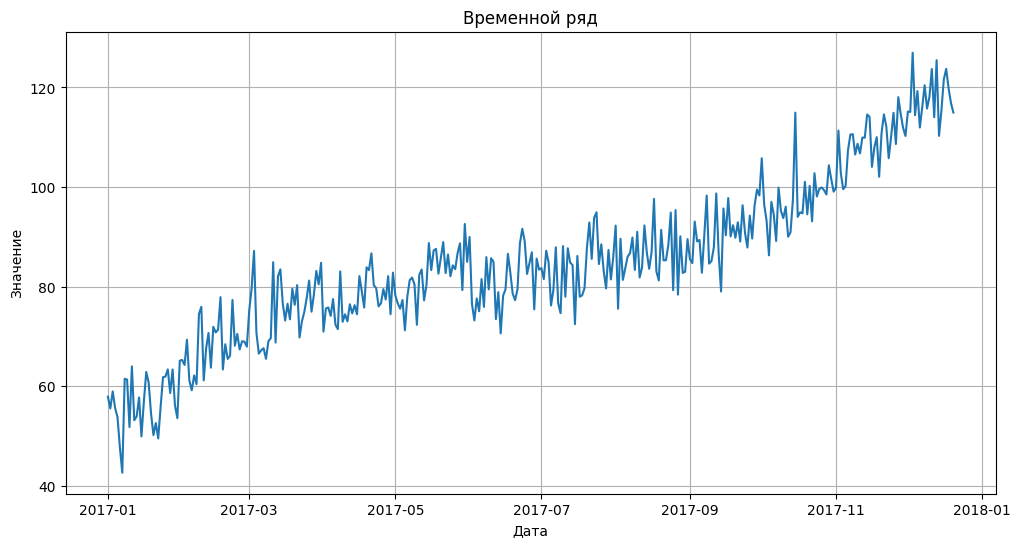

In [4]:
periods = 354
time_index = pd.date_range("1/1/17 0:00", periods=periods, freq='D')
trend = np.linspace(50, 120, periods)
season = 10 * np.sin(2 * np.pi * time_index.month / 12)
noise = np.random.normal(0, 5, periods)

ts = trend + season + noise

plt.figure(figsize=(12, 6))
plt.plot(time_index, ts)
plt.title('Временной ряд')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

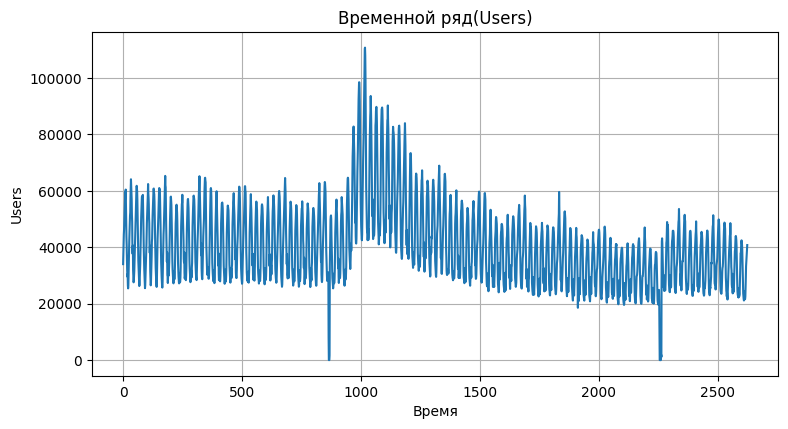

In [5]:
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.plot(df.index, df['Users'])
plt.title('Временной ряд(Users)')
plt.xlabel('Время')
plt.ylabel('Users')
plt.grid(True)

if hasattr(df.index, 'hour'):
    plt.subplot(3, 2, 2)
    df['hour'] = df.index.hour
    hourly_mean = df.groupby('hour')['Users'].mean()
    plt.plot(hourly_mean.index, hourly_mean.values, 'o-')
    plt.title('Среднее по часам')
    plt.xlabel('Час')
    plt.ylabel('Среднее Users')
    plt.grid(True)

if len(df) >= 24 and hasattr(df.index, 'hour'):
    days_to_plot = min(7, len(df) // 24)
    for day in range(days_to_plot):
        day_data = df['Users'].iloc[day*24:(day+1)*24]
        plt.subplot(3, 2, 3)
        plt.plot(range(24), day_data.values, 'o-', label=f'День {day+1}')
    plt.title('Дневные паттерны')
    plt.xlabel('Час дня')
    plt.ylabel('Users')
    plt.legend()
    plt.grid(True)

if hasattr(df.index, 'dayofweek'):
    plt.subplot(3, 2, 4)
    df['dayofweek'] = df.index.dayofweek
    daily_mean = df.groupby('dayofweek')['Users'].mean()
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    plt.bar(days[:len(daily_mean)], daily_mean.values)
    plt.title('Среднее по дням недели')
    plt.xlabel('День недели')
    plt.ylabel('Среднее Users')
    plt.grid(True)

if hasattr(df.index, 'month'):
    plt.subplot(3, 2, 5)
    df['month'] = df.index.month
    monthly_mean = df.groupby('month')['Users'].mean()
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
              'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    plt.bar(months[:len(monthly_mean)], monthly_mean.values)
    plt.title('Среднее по месяцам')
    plt.xlabel('Месяц')
    plt.ylabel('Среднее Users')
    plt.xticks(rotation=45)
    plt.grid(True)

if hasattr(df.index, 'year'):
    plt.subplot(3, 2, 6)
    df['year'] = df.index.year
    yearly_mean = df.groupby('year')['Users'].mean()
    plt.bar(yearly_mean.index.astype(str), yearly_mean.values)
    plt.title('Среднее по годам')
    plt.xlabel('Год')
    plt.ylabel('Среднее Users')
    plt.xticks(rotation=45)
    plt.grid(True)

plt.tight_layout()
plt.show()

Критерий Дики-Фуллера для исходного ряда: p-value=0.1902
Оптимальная лямбда для преобразования Бокса-Кокса: 0.5873
Критерий Дики-Фуллера после Box-Cox: p-value=0.0798


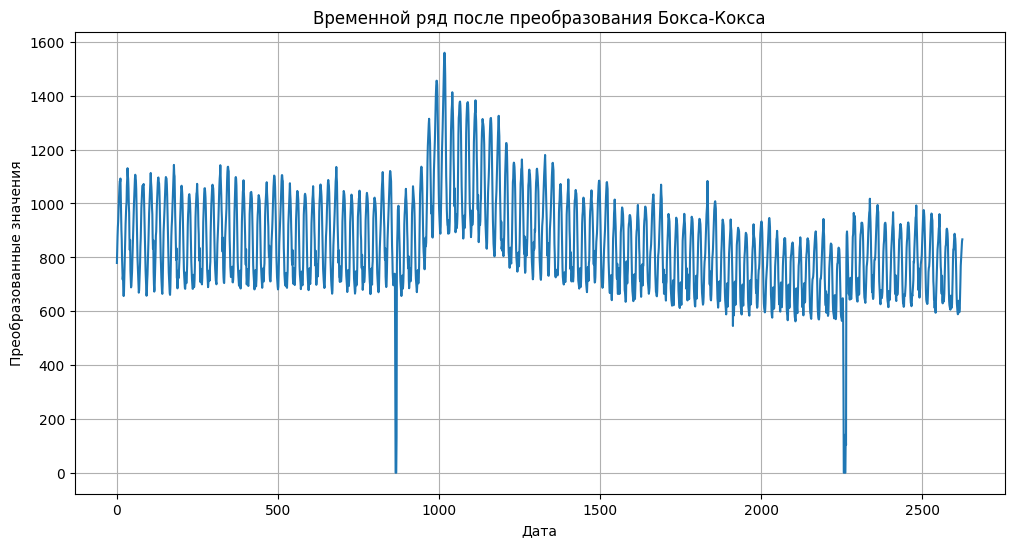

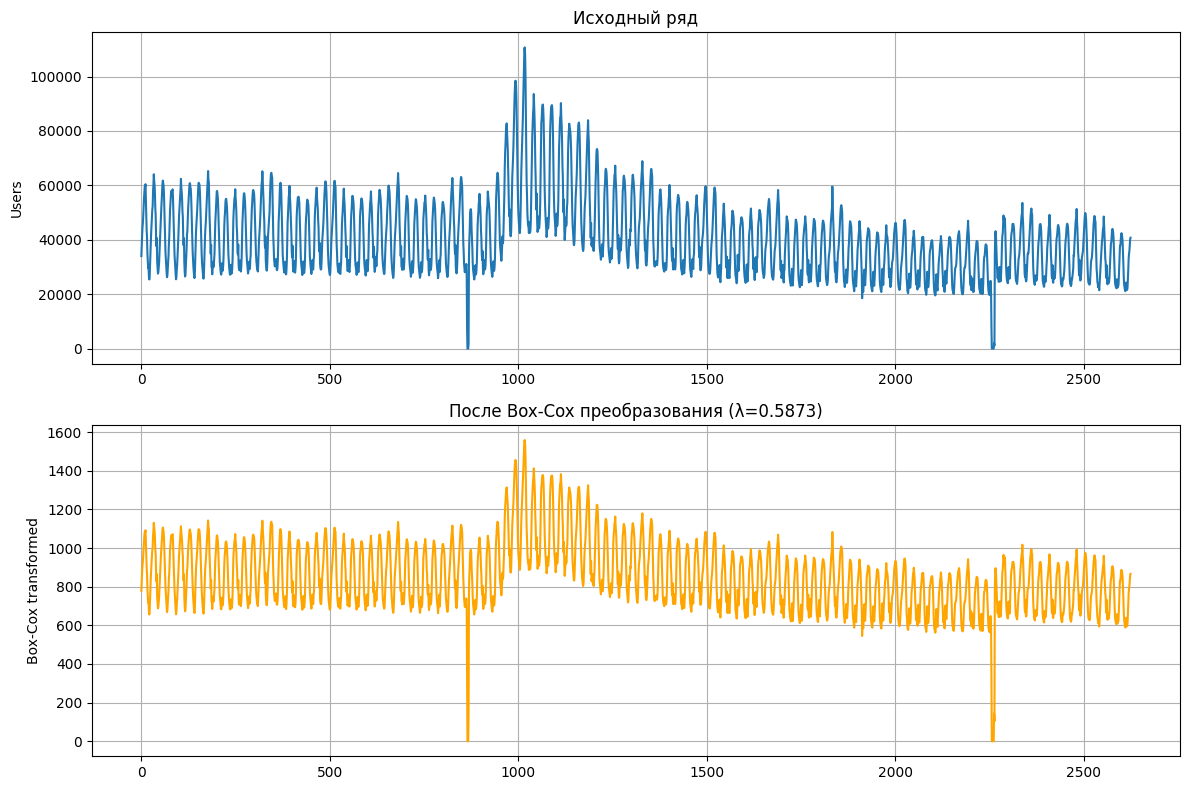

In [6]:
import statsmodels.api as sm
from scipy import stats
from scipy.special import inv_boxcox

p = sm.tsa.stattools.adfuller(df['Users'])[1]
print(f'Критерий Дики-Фуллера для исходного ряда: p-value={p:.4f}')

df['boxcox'], lmbda = stats.boxcox(df['Users'] + 1)
print(f'Оптимальная лямбда для преобразования Бокса-Кокса: {lmbda:.4f}')

p_boxcox = sm.tsa.stattools.adfuller(df['boxcox'])[1]
print(f'Критерий Дики-Фуллера после Box-Cox: p-value={p_boxcox:.4f}')

plt.figure(figsize=(12, 6))
df['boxcox'].plot()
plt.title('Временной ряд после преобразования Бокса-Кокса')
plt.xlabel('Дата')
plt.ylabel('Преобразованные значения')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

df['Users'].plot(ax=axes[0])
axes[0].set_title('Исходный ряд')
axes[0].set_ylabel('Users')
axes[0].grid(True)

df['boxcox'].plot(ax=axes[1], color='orange')
axes[1].set_title(f'После Box-Cox преобразования (λ={lmbda:.4f})')
axes[1].set_ylabel('Box-Cox transformed')
axes[1].grid(True)

plt.tight_layout()
plt.show()

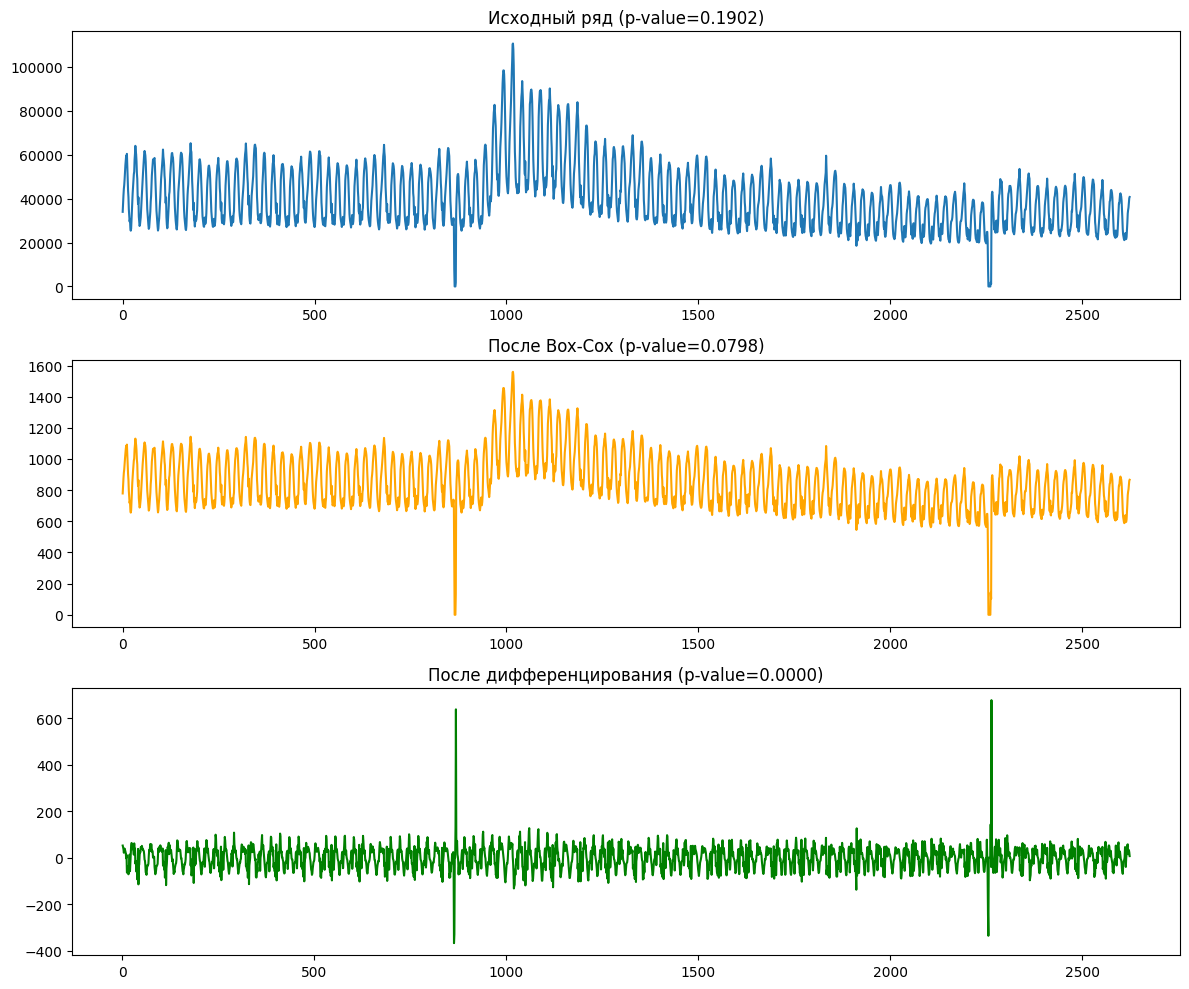

In [22]:
df['diff'] = df['boxcox'].diff().dropna() #удаление тренда(дифференцирование)
p_diff = sm.tsa.stattools.adfuller(df['diff'].dropna())[1]

df['seasonal_diff'] = df['boxcox'].diff(7).dropna()  #для недельной сезонности
p_seasonal = sm.tsa.stattools.adfuller(df['seasonal_diff'].dropna())[1]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df['Users'].plot(ax=axes[0])
axes[0].set_title(f'Исходный ряд (p-value={0.1902:.4f})')

df['boxcox'].plot(ax=axes[1], color='orange')
axes[1].set_title(f'После Box-Cox (p-value={0.0798:.4f})')

if p_diff < 0.05:
    df['diff'].plot(ax=axes[2], color='green')
    axes[2].set_title(f'После дифференцирования (p-value={p_diff:.4f})')

plt.tight_layout()
plt.show()

In [8]:
s = df['boxcox'].dropna()
indx = int(len(s) * 0.8)
train = s.iloc[:indx]
test = s.iloc[indx:]
print(f"Обучение: {len(train)}")
print(f"Тест: {len(test)}")

Обучение: 2100
Тест: 525


In [9]:
def split_data(data, window=7, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - window - forecast_horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+forecast_horizon])
    return np.array(X), np.array(y)

In [10]:
window = 356
forecast_horizon = 30

X_train, y_train = split_data(train, window, forecast_horizon)
X_test, y_test = split_data(test, window, forecast_horizon)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (1715, 356)
y_train: (1715, 30)


In [ ]:
import tensorflow as tf
import keras

model = keras.Sequential([
    keras.Input(shape=(356,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(30)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"train MAE: {train_mae:.4f}, test MAE: {test_mae:.4f}")

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 392071.6250 - mae: 475.3934
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 68255.6484 - mae: 183.6544 
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 23400.8145 - mae: 115.2477
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20662.7891 - mae: 107.2752
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18420.7012 - mae: 100.4908
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16670.1367 - mae: 94.5178
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14391.0166 - mae: 86.2820
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12564.4326 - mae: 79.5327
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10901.1689 - mae: 72.9767
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9061.8516 - mae: 64.5720
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8172.3267 - mae: 60.7421
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7465.4321

Средняя MAE: 51.51


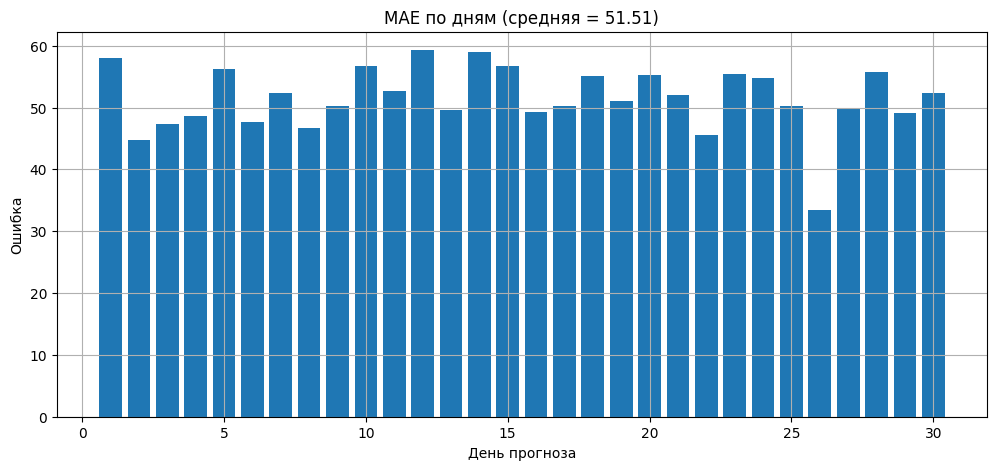

In [ ]:
y_pred = model.predict(X_test, verbose=0)

mae = mean_absolute_error(y_test, y_pred)
mae_per_day = np.mean(np.abs(y_test - y_pred), axis=0)

print(f"Средняя MAE: {mae:.2f}")

plt.figure(figsize=(12, 5))
plt.bar(range(1, 31), mae_per_day)
plt.title(f'MAE по дням (средняя = {mae:.2f})')
plt.xlabel('День прогноза')
plt.ylabel('Ошибка')
plt.grid(True)
plt.show()

In [ ]:
window = 30
forecast_horizon = 30

X_train, y_train = split_data(train, window, forecast_horizon)
X_test, y_test = split_data(test, window, forecast_horizon)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (2041, 30)
y_train: (2041, 30)


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(30)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"train MAE: {train_mae:.4f}, test MAE: {test_mae:.4f}")

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 332039.1250 - mae: 452.0359
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30761.4805 - mae: 139.8950
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20033.2910 - mae: 116.5196
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17877.1582 - mae: 107.6480
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14692.6602 - mae: 94.1026
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12070.8262 - mae: 82.4338
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10924.1748 - mae: 76.3458
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10069.6914 - mae: 72.1947
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9308.4512 - mae: 68.5992
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8444.5088 - mae: 64.5605
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7657.0874 - mae: 60.7613
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7011.9443 - 

Средняя MAE: 53.64


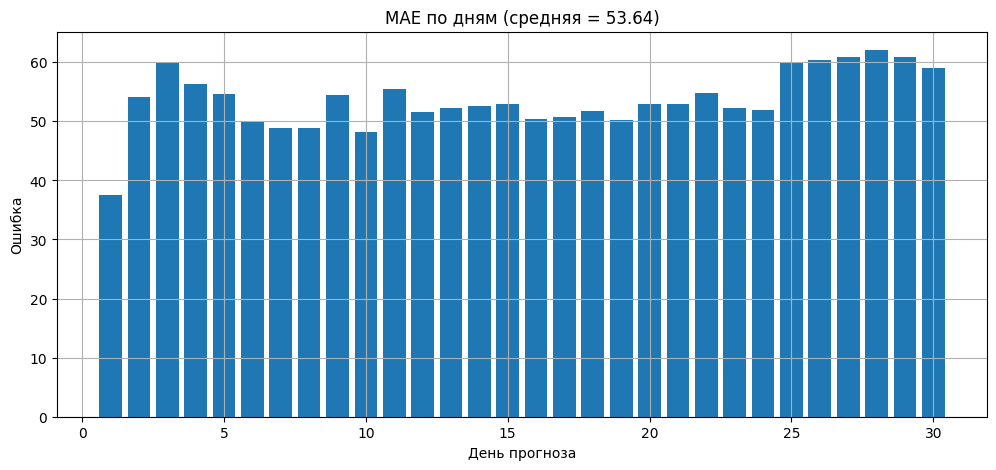

In [ ]:
y_pred = model.predict(X_test, verbose=0)

mae = mean_absolute_error(y_test, y_pred)
mae_per_day = np.mean(np.abs(y_test - y_pred), axis=0)

print(f"Средняя MAE: {mae:.2f}")

plt.figure(figsize=(12, 5))
plt.bar(range(1, 31), mae_per_day)
plt.title(f'MAE по дням (средняя = {mae:.2f})')
plt.xlabel('День прогноза')
plt.ylabel('Ошибка')
plt.grid(True)
plt.show()

In [ ]:
window = 90
forecast_horizon = 30

X_train, y_train = split_data(train, window, forecast_horizon)
X_test, y_test = split_data(test, window, forecast_horizon)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (1981, 90)
y_train: (1981, 30)


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(90,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(30)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"train MAE: {train_mae:.4f}, test MAE: {test_mae:.4f}")

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 231183.1719 - mae: 347.1266
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20491.9395 - mae: 113.3946
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16087.1338 - mae: 97.3787 
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12908.4609 - mae: 84.2204
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10458.1973 - mae: 73.3125
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8953.5146 - mae: 66.1461
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7973.4468 - mae: 61.2869
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7313.6348 - mae: 57.6664
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6853.0708 - mae: 55.2465
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6570.7002 - mae: 53.8928
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6335.5977 - mae: 52.4195
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6061.6929 - mae:

Средняя MAE: 72.06


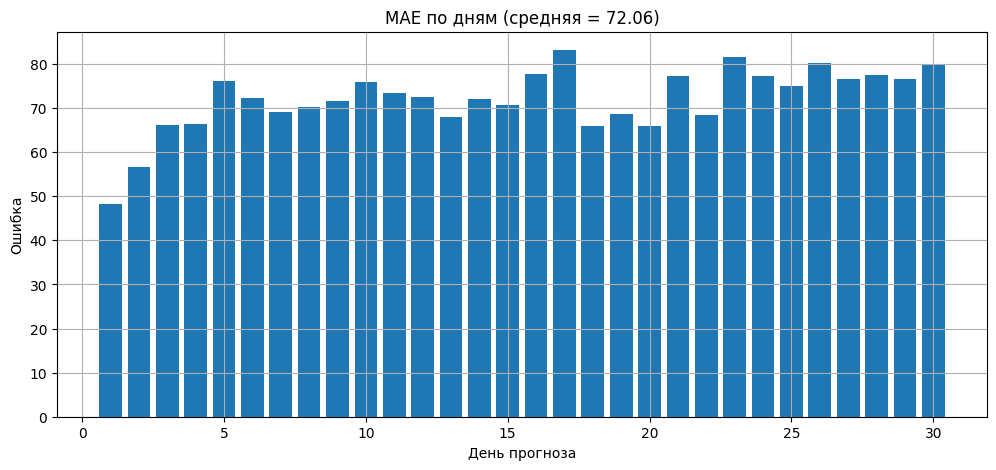

In [ ]:
y_pred = model.predict(X_test, verbose=0)

mae = mean_absolute_error(y_test, y_pred)
mae_per_day = np.mean(np.abs(y_test - y_pred), axis=0)

print(f"Средняя MAE: {mae:.2f}")

plt.figure(figsize=(12, 5))
plt.bar(range(1, 31), mae_per_day)
plt.title(f'MAE по дням (средняя = {mae:.2f})')
plt.xlabel('День прогноза')
plt.ylabel('Ошибка')
plt.grid(True)
plt.show()

In [14]:
df['Time'] = pd.to_datetime(df['Time'])
df['month'] = df['Time'].dt.month

df['season_winter'] = (df['month'].isin([12, 1, 2])).astype(int)
df['season_spring'] = (df['month'].isin([3, 4, 5])).astype(int)
df['season_summer'] = (df['month'].isin([6, 7, 8])).astype(int)
df['season_autumn'] = (df['month'].isin([9, 10, 11])).astype(int)

boxcox_values = df['boxcox'].values

winter_data = boxcox_values[df['season_winter'] == 1]
spring_data = boxcox_values[df['season_spring'] == 1]

WINDOW = 178
HORIZON = 30
LAMBDA = 0.5873

min_required = WINDOW + HORIZON

def create_sequences(data, window=WINDOW, horizon=HORIZON):
    if data is None:
        return None, None
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+horizon])
    return np.array(X), np.array(y)

def train_model(data, season_name):
    if data is None:
        return None, None

    X, y = create_sequences(data)
    if X is None:
        return None, None

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = keras.Sequential([
        keras.Input(shape=(WINDOW,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(HORIZON)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    _, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"  Test MAE: {test_mae:.2f}")
    return model, test_mae

In [15]:
winter_model, winter_mae = train_model(winter_data, "зима")
spring_model, spring_mae = train_model(spring_data, "весна")

  Test MAE: 61.16
  Test MAE: 45.58


In [16]:
def predict(model, data):
    if model is None or data is None:
        return None

    last_data = data[-WINDOW:]
    pred = model.predict(last_data.reshape(1, -1), verbose=0)[0]
    return inv_boxcox(pred, LAMBDA) - 1

In [17]:
winter_pred = predict(winter_model, winter_data)
spring_pred = predict(spring_model, spring_data)

In [19]:
if winter_pred is not None or spring_pred is not None:
    print(f"{'День':<6} {'Зима (пользователи)':<20} {'Весна (пользователи)':<20}")

    for i in range(30):
        winter_val = f"{winter_pred[i]:.0f}" if winter_pred is not None else "---"
        spring_val = f"{spring_pred[i]:.0f}" if spring_pred is not None else "---"
        print(f"{i+1:<6} {winter_val:<20} {spring_val:<20}")

День   Зима (пользователи)  Весна (пользователи)
1      31645                42148               
2      37249                41375               
3      38549                40421               
4      41608                36145               
5      47816                34146               
6      53477                31626               
7      54709                29450               
8      58915                26023               
9      60132                25029               
10     60681                22994               
11     58202                24496               
12     54803                23940               
13     52926                23099               
14     49118                25708               
15     40367                28247               
16     39736                27634               
17     34830                33808               
18     33350                35203               
19     30948                37248               
20     28091        

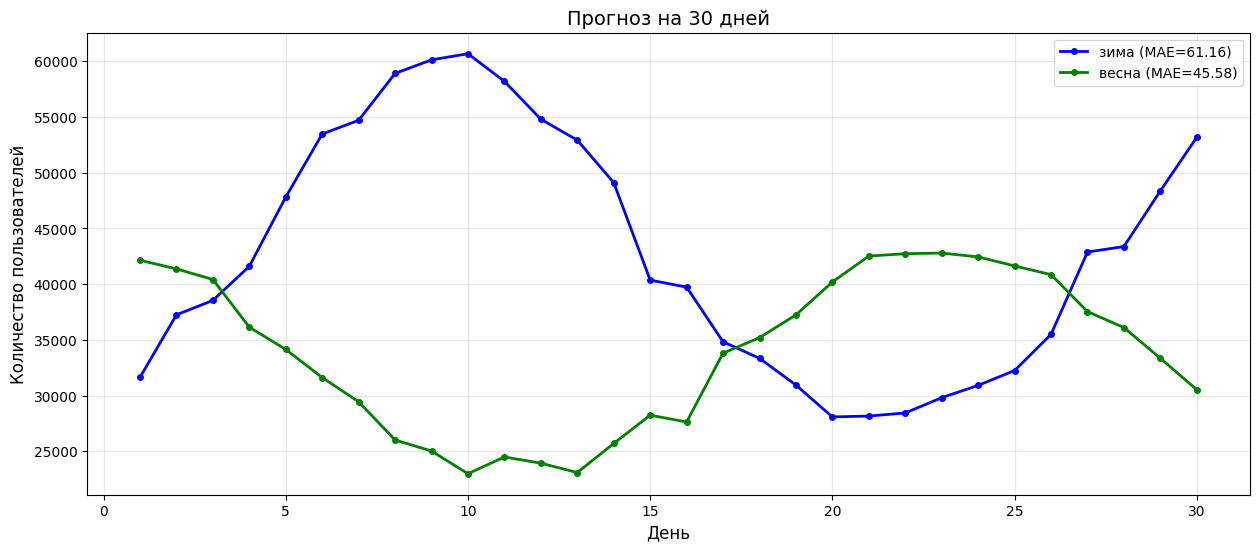

In [18]:
plt.figure(figsize=(15, 6))
days = range(1, HORIZON+1)

if winter_pred is not None:
    plt.plot(days, winter_pred, 'b-o', label=f'зима (MAE={winter_mae:.2f})', linewidth=2, markersize=4)
if spring_pred is not None:
    plt.plot(days, spring_pred, 'g-o', label=f'весна (MAE={spring_mae:.2f})', linewidth=2, markersize=4)

if winter_pred is not None or spring_pred is not None:
    plt.title('Прогноз на 30 дней', fontsize=14)
    plt.xlabel('День', fontsize=12)
    plt.ylabel('Количество пользователей', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()